In [1]:
import os
import pickle
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import re 

import xgboost as xgb
import lightgbm
import catboost
from sklearn import ensemble
from sklearn import dummy
from sklearn import linear_model
from sklearn import svm
from sklearn import neural_network
from sklearn import metrics
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import loguniform
import scipy
import argparse
import shap
shap.initjs()

from misc import save_model, load_model, regression_results, grid_search_cv, calculate_regression_metrics, supervised_learning_steps, get_CV_results

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
#Get the setting with different X_trains and X_tests
train_options = ["../Data/Training_Set_Var_with_Drug_Embedding_Cell_Info.pkl",
                 "../Data/Training_Set_Var_with_Drug_MFP_Cell_Info.pkl",
                 ".."]
test_options = ["../Data/Test_Set_Var_with_Drug_Embedding_Cell_Info.pkl",
                "../Data/Test_Set_Var_with_Drug_MFP_Cell_Info.pkl",
                ".."]
data_type_options = ["LS_Feat_Var","MFP_Feat_Var"]

In [3]:
input_option = 1                                                  #Choose 0 for LS for Drug and LS for Cell Line , 1 for MFP for Drug and LS for Cell Line 
classification_task = False
data_type = data_type_options[input_option]

#Get the data for your choice: LS or MFP
print("Loaded training file")
big_train_df = pd.read_pickle(train_options[input_option],compression="zip")
big_test_df = pd.read_pickle(test_options[input_option],compression="zip")
big_train_df = big_train_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
big_test_df = big_test_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
total_length = len(big_train_df.columns)
if (input_option==0):
    #Consider only those columns which have numeric values
    metadata_X_train,X_train, Y_train = big_train_df.loc[:,["dbgap_rnaseq_sample","inhibitor"]], big_train_df.iloc[:,[1,4]+[*range(6,262,1)]+[*range(288,total_length,1)]], big_train_df["auc"].to_numpy().flatten()
    metadata_X_test,X_test, Y_test = big_test_df.loc[:,["dbgap_rnaseq_sample","inhibitor"]], big_test_df.iloc[:,[1,4]+[*range(6,262,1)]+[*range(288,total_length,1)]], big_test_df["auc"].to_numpy().flatten()
elif (input_option==1):
    metadata_X_train,X_train, Y_train = big_train_df.loc[:,["dbgap_rnaseq_sample","inhibitor"]], big_train_df.iloc[:,[1,4]+[*range(6,1030,1)]+[*range(1056,total_length,1)]], big_train_df["auc"].to_numpy().flatten()
    metadata_X_test,X_test, Y_test = big_test_df.loc[:,["dbgap_rnaseq_sample","inhibitor"]], big_test_df.iloc[:,[1,4]+[*range(6,1030,1)]+[*range(1056,total_length,1)]], big_test_df["auc"].to_numpy().flatten()

#Keep only numeric training and test set and those which have no Nans
X_train_numerics_only = X_train.select_dtypes(include=np.number)
X_test_numerics_only = X_test[X_train_numerics_only.columns]
print("Shape of training set after removing non-numeric cols")
print(X_train_numerics_only.shape)
print(X_test_numerics_only.shape)


nan_cols = [i for i in X_train_numerics_only.columns if X_train_numerics_only[i].isnull().any()]
rev_X_train = X_train_numerics_only.drop(nan_cols,axis=1)
rev_X_test = X_test_numerics_only.drop(nan_cols,axis=1)
print("Shape of training set after removing cols with NaNs")
print(rev_X_train.shape)
print(rev_X_test.shape)

Loaded training file
Shape of training set after removing non-numeric cols
(34387, 2346)
(19184, 2346)
Shape of training set after removing cols with NaNs
(34387, 2333)
(19184, 2333)


In [4]:
catboost_gs = load_model("catboost_models/catboost_"+data_type+"_regressor_gs.pk")
results = get_CV_results(catboost_gs,pd.DataFrame(rev_X_train),Y_train,n_splits=5)
print(results)

Load model to file: ../Models/catboost_models/catboost_MFP_Feat_Var_regressor_gs.pk
[18.246, 22.554, 21.557, 21.696, 21.456] [27.131, 33.71, 32.745, 32.557, 33.453] [0.748, 0.686, 0.772, 0.68, 0.738]
(21.102, 1.48, 31.919, 2.432, 0.725, 0.036, 0.851, 0.021, 0.85, 0.017)


Load model to file: ../Models/catboost_models/catboost_MFP_Feat_Var_regressor_gs.pk
(21.102, 32.011, 0.731, 0.855, 0.854)
Finished writing predictions


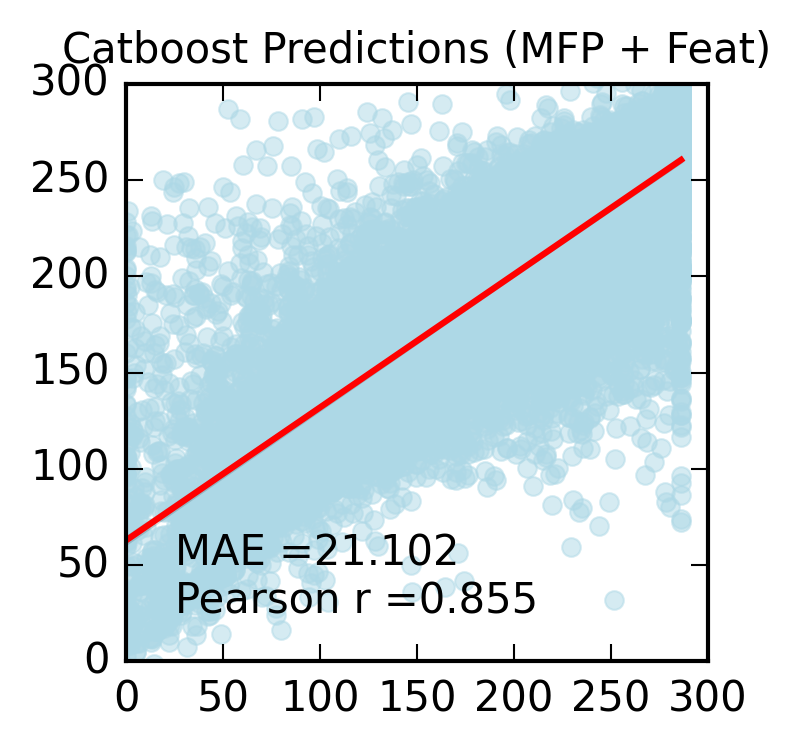

In [5]:
#Test the linear regression model on separate test set  
catboost_gs = load_model("catboost_models/catboost_"+data_type+"_regressor_gs.pk")
np.max(catboost_gs.cv_results_["mean_test_score"])
catboost_best = catboost_gs.best_estimator_
y_pred_catboost=catboost_best.predict(rev_X_train)
test_metrics=calculate_regression_metrics(Y_train,y_pred_catboost)
print(test_metrics)

#Write the prediction of LR model
metadata_X_train['predictions']=y_pred_catboost
metadata_X_train['labels']=Y_train
metadata_X_train.to_csv("../Results/Catboost_"+data_type+"_supervised_train_predictions.csv",index=False,sep="\t")
print("Finished writing predictions")

fig = plt.figure()
plt.style.use('classic')
fig.set_size_inches(2.5,2.5)
fig.set_dpi(300)
fig.set_facecolor("white")

ax = sn.regplot(x="labels", y="predictions", data=metadata_X_train, scatter_kws={"color": "lightblue",'alpha':0.5}, 
                line_kws={"color": "red"})
ax.axes.set_title("Catboost Predictions (MFP + Feat)",fontsize=10)
ax.set_xlim(0, 300)
ax.set_ylim(0, 300)
ax.set_xlabel("",fontsize=10)
ax.set_ylabel("",fontsize=10)
ax.tick_params(labelsize=10, color="black")
plt.text(25, 25, 'Pearson r =' +str(test_metrics[3]), fontsize = 10)
plt.text(25, 50, 'MAE ='+str(test_metrics[0]),fontsize=10)
outfilename = "../Results/Catboost_"+data_type+"_supervised_train_prediction.pdf"
plt.savefig(outfilename, bbox_inches="tight")

In [6]:
#Get the shap explainer and shapley values
explainer = shap.TreeExplainer(catboost_best)
shap_values = explainer(rev_X_train, Y_train)

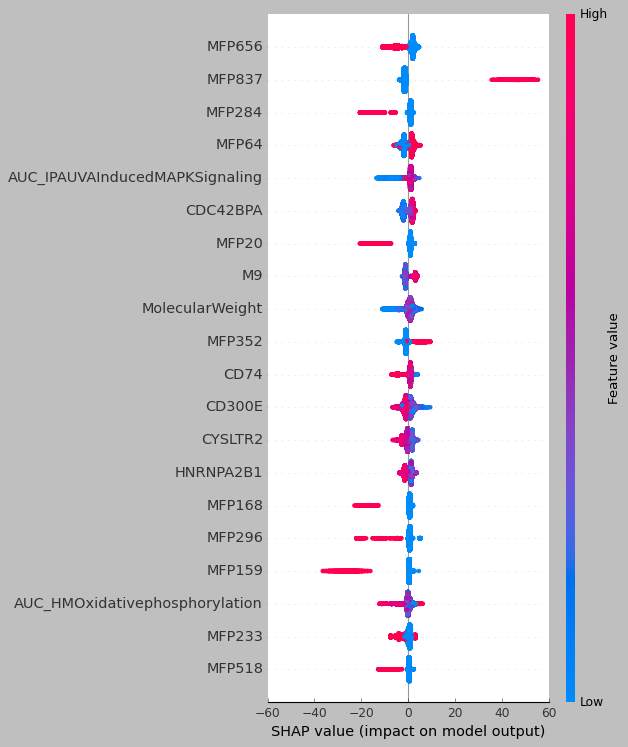

In [7]:
#shap summary plot plotting
import matplotlib.pyplot as pl
shap.summary_plot(shap_values, max_display=20, show=False)
#pl.savefig("../Results/CatBoost_SHAP_Summary.svg",dpi=300) #.png,.pdf will also support here
pl.show()

In [8]:
## Top features include molecular fingerprints, gene expression of genes like CD300E, CD74, HNRNPA2B1, 
## distance of drug from pathways like oxidative phosphorylation and UVA induced MAPK signaling

y_pred_test_catboost=catboost_best.predict(rev_X_test)
test_metrics=calculate_regression_metrics(Y_test,y_pred_test_catboost)
print(test_metrics)

metadata_X_test["Y"] = Y_test
metadata_X_test["Y_pred"] = y_pred_test_catboost

(39.044, 52.032, 0.439, 0.663, 0.652)


In [9]:
## See the predictions with metadata
metadata_X_test["MAE"] = np.abs(metadata_X_test["Y"]-metadata_X_test["Y_pred"])
rev_metadata_X_test = metadata_X_test.sort_values(by=["Y"],ascending=False)

sensitive_X_test = rev_metadata_X_test[rev_metadata_X_test["Y"]>270]
resistant_X_test = rev_metadata_X_test[rev_metadata_X_test["Y"]<10]

sensitive_X_test = sensitive_X_test.sort_values(by=["MAE"],ascending=True)
resistant_X_test = resistant_X_test.sort_values(by=["MAE"],ascending=True)

#Get top 2 sensitive samples with near perfect performance and top 2 resistant samples with lowest MAE
top2_resistant_X_test = resistant_X_test.iloc[:2,:]
top2_sensitive_X_test = sensitive_X_test.iloc[:2,:]

In [10]:
## Get the test shap values
test_shap_values = explainer(rev_X_test, Y_test)
resistant_indices = top2_resistant_X_test.index
sensitive_indices = top2_sensitive_X_test.index

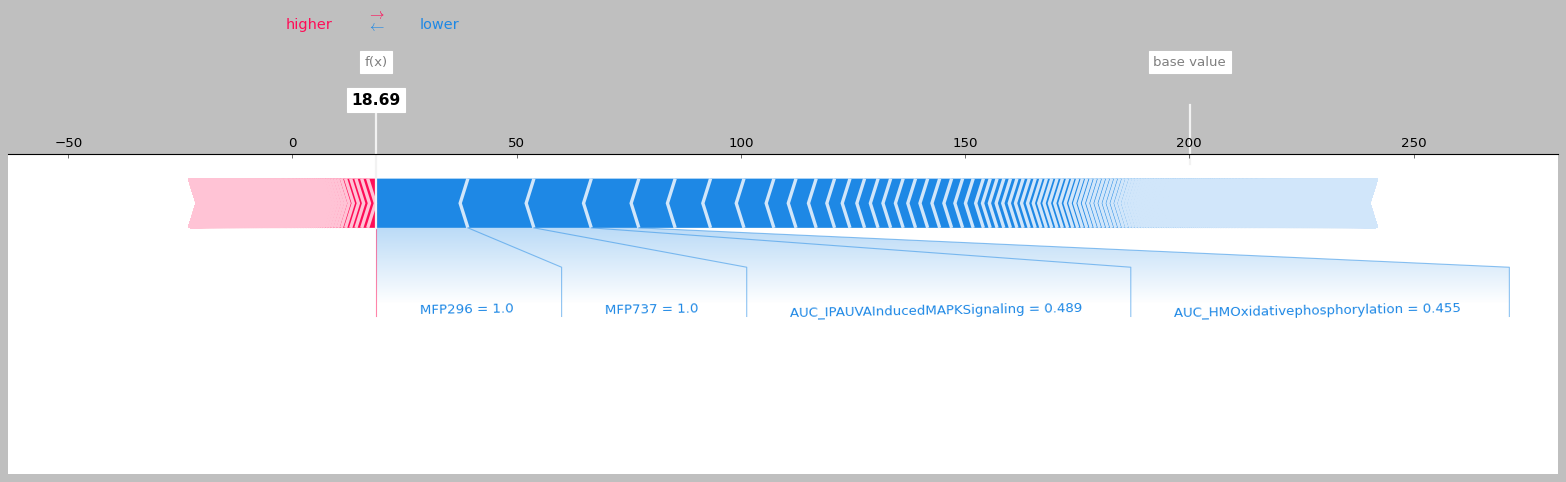

In [11]:
shap.plots.force(test_shap_values[resistant_indices[0], ...], text_rotation=True, matplotlib=True, figsize=[25,5], contribution_threshold=0.02, show=False)
#pl.savefig("../Results/CatBoost_SHAP_resistance_sample1.svg",dpi=300) #.png,.pdf will also support here
pl.show()

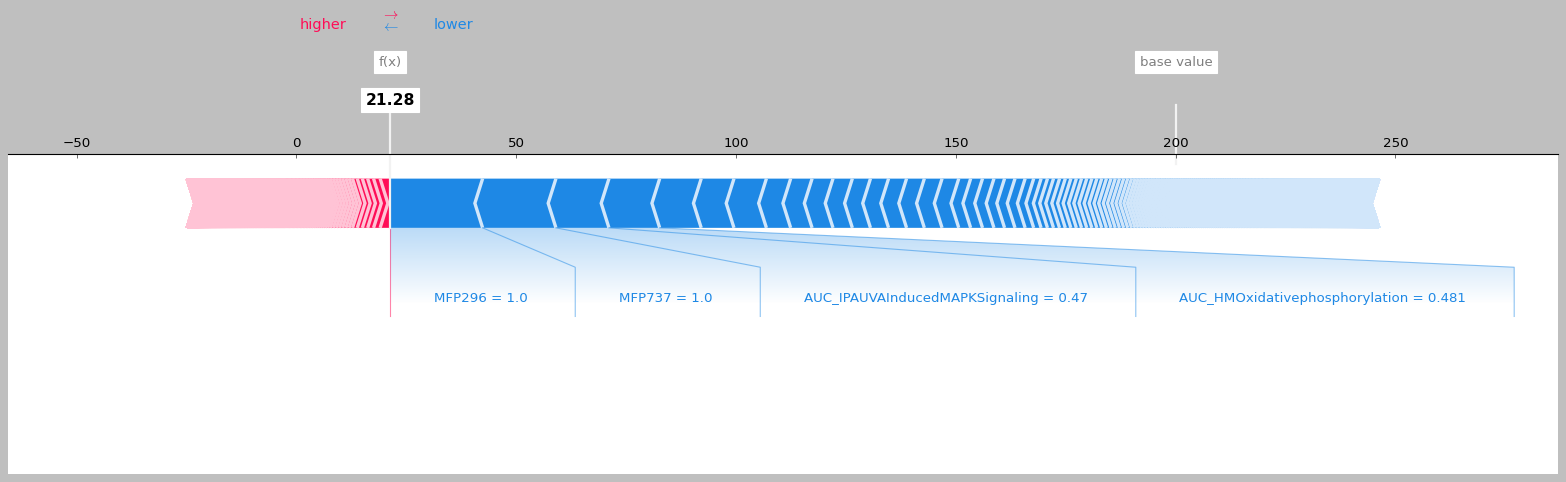

In [12]:
shap.plots.force(test_shap_values[resistant_indices[1],...], matplotlib=True, figsize=[25,5], contribution_threshold=0.02, show=False)
#pl.savefig("../Results/CatBoost_SHAP_resistance_sample2.svg",dpi=300) #.png,.pdf will also support here
pl.show()

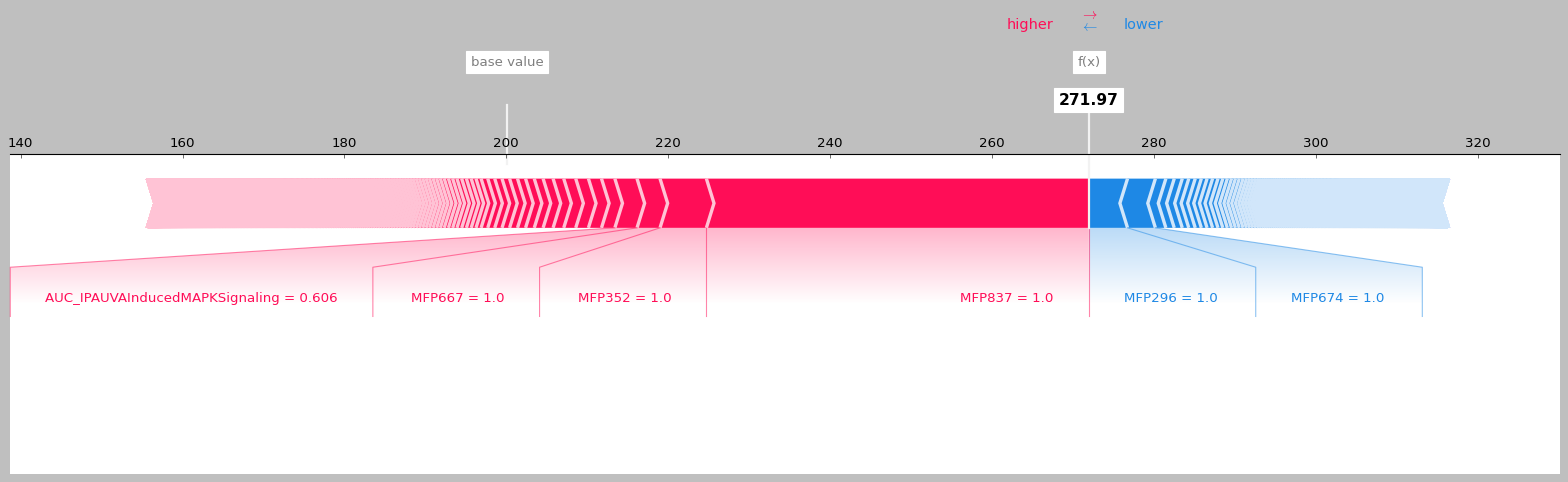

In [13]:
shap.plots.force(test_shap_values[sensitive_indices[0],...],matplotlib=True, figsize=[25,5], contribution_threshold=0.02,show=False)
#pl.savefig("../Results/CatBoost_SHAP_sensitive_sample1.svg",dpi=300) #.png,.pdf will also support here
pl.show()

In [ ]:
shap.plots.force(test_shap_values[sensitive_indices[1],...],matplotlib=True, figsize=[25,5], contribution_threshold=0.015, show=False)
#pl.savefig("../Results/CatBoost_SHAP_sensitive_sample2.svg",dpi=300) #.png,.pdf will also support here
pl.show()

In [ ]:
top2_resistant_X_test

In [ ]:
top2_sensitive_X_test